# ESG Scores — Exploratory Data Analysis

Explore the `esg_scores.csv` dataset produced by `make esg_scores`.  
Each row is one earnings call. Scores are TF-IDF-weighted sums of ESG dictionary word weights, broken down by topic (Environmental / Social / Governance) and segment (presentation vs. Q&A answers).

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA_DIR = Path("../data/processed")

# color palette
BLUE      = "#1c4e80"   # primary blue  — Presentation
RED       = "#c0392b"   # primary red   — Q&A Answers
BLUE_LIGHT = "#5b9bd5"  # lighter blue  — third category

## 2. Load the Dataset

In [2]:
df = pd.read_csv(DATA_DIR / "esg_scores.csv", low_memory=False)

# Ensure numeric types for score columns
score_cols = [c for c in df.columns if c.startswith("pres_esg") or c.startswith("ans_esg")]
df[score_cols] = df[score_cols].apply(pd.to_numeric, errors="coerce")
df["year_call"] = pd.to_numeric(df["year_call"], errors="coerce")

print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
df.head(3)

Loaded 5,958 rows × 24 columns


,permco,permno,gvkey,comnam,filename,date_call,year_call,month_call,day_call,presentation_found,...,pres_esg_governance,pres_esg_social,pres_esg_total,pres_found,ans_esg_environmental,ans_esg_environmental (additon lmo 2022),ans_esg_governance,ans_esg_social,ans_esg_total,ans_found
0,35,11739,1259,ALFACELL CORP,1665733.txt,15oct2007,2007,10,15,1,...,2.380068,0.209061,2.589129,True,0.0,0.0,1.577028,0.546299,2.123328,True
1,35,11739,1259,ALFACELL CORP,1710463.txt,10dec2007,2007,12,10,1,...,1.595154,0.511929,2.107083,True,0.0,0.0,1.312329,1.113576,2.425905,True
2,35,11739,1259,ALFACELL CORP,1784915.txt,07mar2008,2008,3,7,1,...,1.253106,1.144295,2.397401,True,0.0,0.0,1.455612,1.266306,2.721918,True


## 3. Inspect the Data

In [3]:
df[score_cols].describe().round(4)

,pres_esg_environmental,pres_esg_environmental (additon lmo 2022),pres_esg_governance,pres_esg_social,pres_esg_total,ans_esg_environmental,ans_esg_environmental (additon lmo 2022),ans_esg_governance,ans_esg_social,ans_esg_total
count,5958.0000,5958.0000,5958.0000,5958.0000,5958.0000,5958.0000,5958.0000,5958.0000,5958.0000,5958.0000
mean,0.2335,0.0400,1.9573,0.7539,2.9846,0.2204,0.0386,1.4316,0.7991,2.4898
std,0.3941,0.1079,0.8400,0.5776,0.8243,0.3693,0.1210,0.7751,0.6024,0.8721
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,1.3643,0.2713,2.4339,0.0000,0.0000,0.8908,0.2889,1.9892
50%,0.0000,0.0000,2.0193,0.6654,2.9761,0.0000,0.0000,1.4337,0.7360,2.5621
75%,0.3120,0.0000,2.5371,1.1594,3.5384,0.3074,0.0000,1.9581,1.2131,3.0624
max,2.6551,1.2747,5.3618,3.1433,6.0827,2.6698,1.0000,3.9809,3.0722,5.0553


## 4. ESG Score Distributions

Distribution of total ESG scores for presentations and Q&A answers. High-scoring calls are rare — most calls have near-zero ESG content.

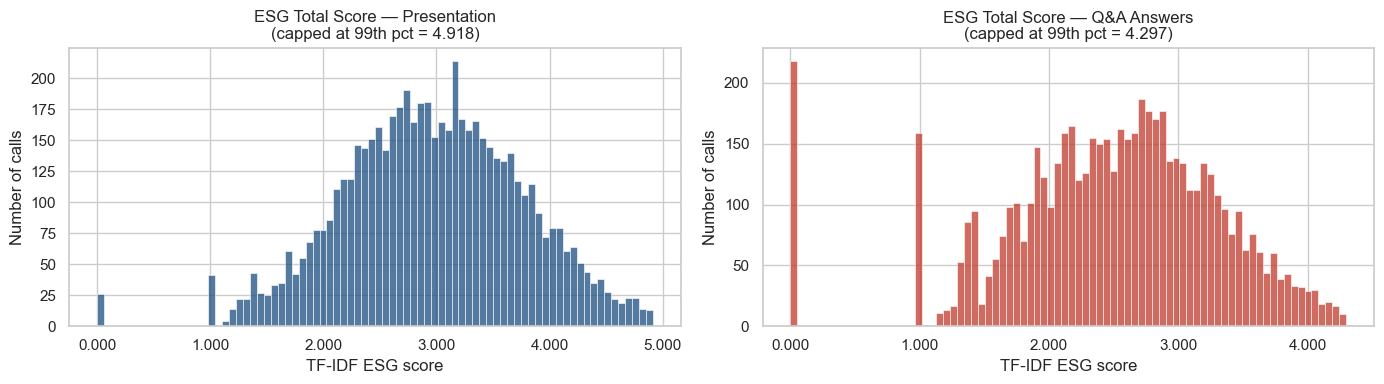

Percentage of calls with zero ESG score:
  pres_esg_total: 0.4%
  ans_esg_total: 3.7%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, label, color in zip(
    axes,
    ["pres_esg_total", "ans_esg_total"],
    ["Presentation", "Q&A Answers"],
    [BLUE, RED],
):
    data = df[col].dropna()
    cap = data.quantile(0.99)
    sns.histplot(data[data <= cap], bins=80, ax=ax, color=color)
    ax.set_title(f"ESG Total Score — {label}\n(capped at 99th pct = {cap:.3f})")
    ax.set_xlabel("TF-IDF ESG score")
    ax.set_ylabel("Number of calls")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

plt.tight_layout()
plt.show()

print("Percentage of calls with zero ESG score:")
for col in ["pres_esg_total", "ans_esg_total"]:
    pct_zero = (df[col] == 0).sum() / df[col].notna().sum() * 100
    print(f"  {col}: {pct_zero:.1f}%")

## 5. ESG Scores Over Time

Average ESG scores by year — shows whether managers discuss ESG topics more in recent years.

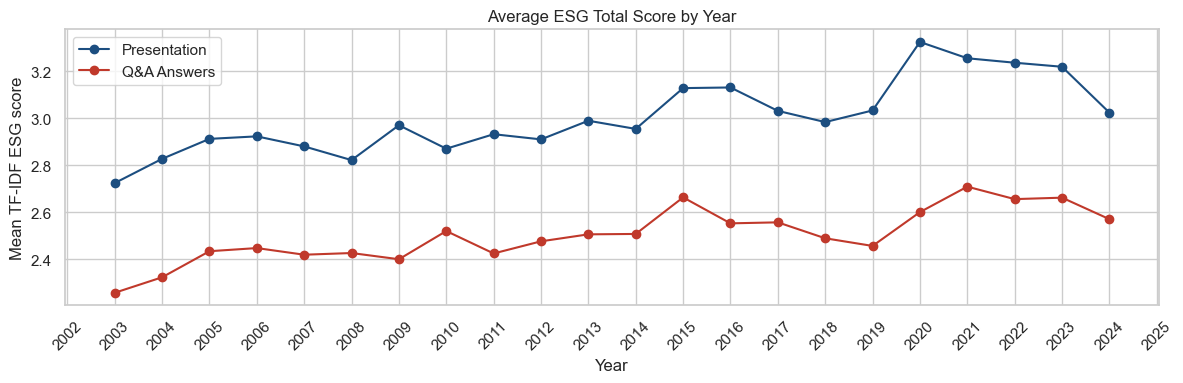

In [5]:
yearly = (
    df.groupby("year_call")[["pres_esg_total", "ans_esg_total"]]
    .mean()
    .reset_index()
    .rename(columns={"pres_esg_total": "Presentation", "ans_esg_total": "Q&A Answers"})
)

fig, ax = plt.subplots(figsize=(12, 4))
yearly.plot(x="year_call", y=["Presentation", "Q&A Answers"], ax=ax,
            marker="o", color=[BLUE, RED])
ax.set_title("Average ESG Total Score by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Mean TF-IDF ESG score")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. E / S / G Topic Breakdown

How are scores split across Environmental, Social, and Governance topics?

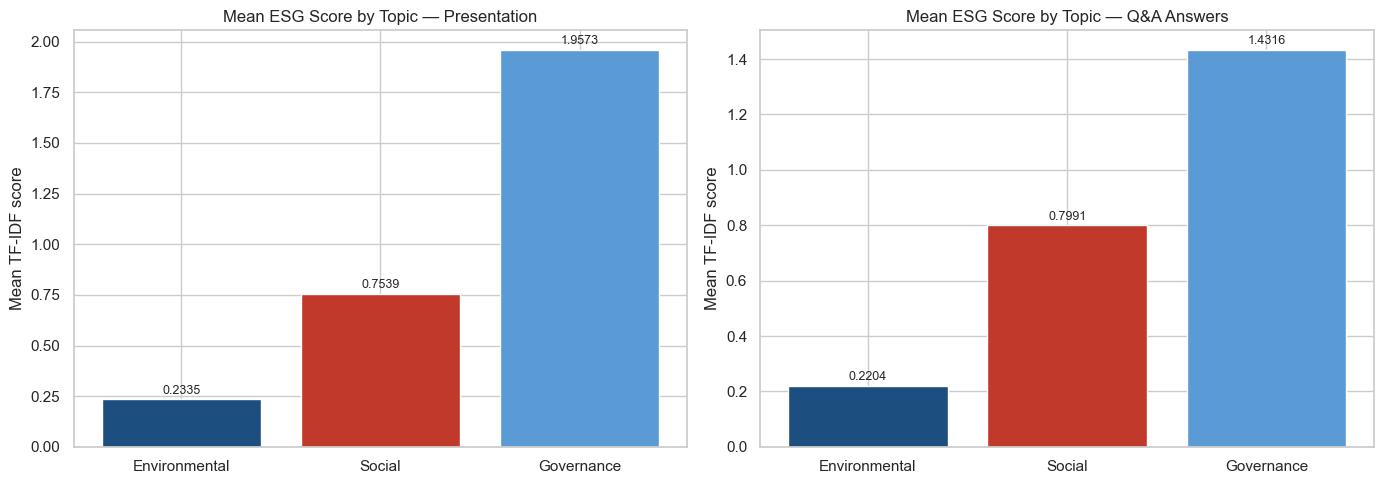

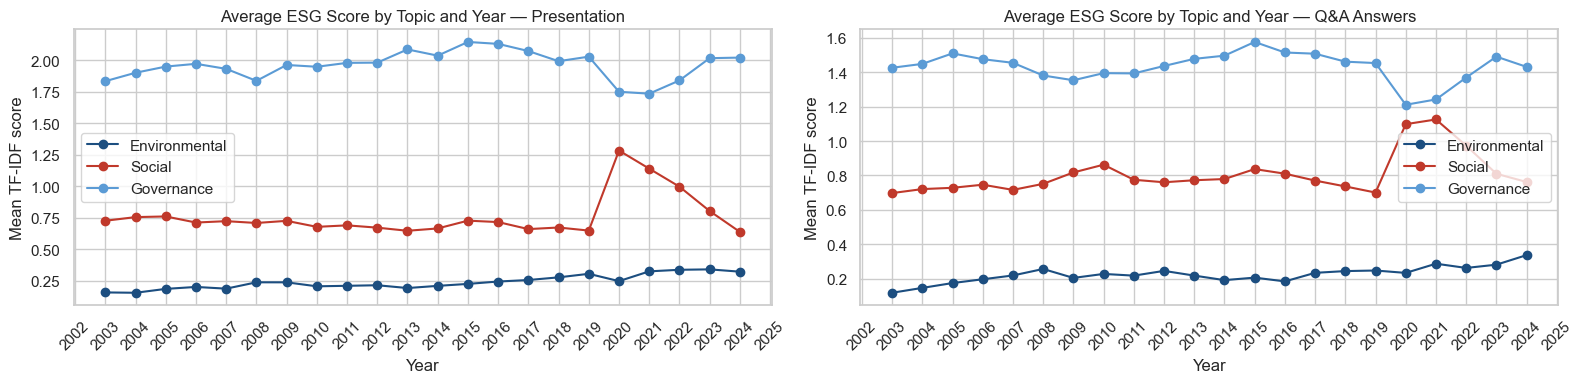

In [6]:
topic_cols = {
    "Presentation": ["pres_esg_environmental", "pres_esg_social", "pres_esg_governance"],
    "Q&A Answers":  ["ans_esg_environmental",  "ans_esg_social",  "ans_esg_governance"],
}
labels = ["Environmental", "Social", "Governance"]
colors = [BLUE, RED, BLUE_LIGHT]

# --- Mean scores by topic (bar charts) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (segment, cols) in zip(axes, topic_cols.items()):
    means = df[cols].mean().values
    bars = ax.bar(labels, means, color=colors)
    ax.bar_label(bars, fmt="%.4f", padding=2, fontsize=9)
    ax.set_title(f"Mean ESG Score by Topic — {segment}")
    ax.set_ylabel("Mean TF-IDF score")

plt.tight_layout()
plt.show()

# --- Yearly breakdown by topic: Presentation AND Q&A answers ---
rename_pres = {
    "pres_esg_environmental": "Environmental",
    "pres_esg_social": "Social",
    "pres_esg_governance": "Governance",
}
rename_ans = {
    "ans_esg_environmental": "Environmental",
    "ans_esg_social": "Social",
    "ans_esg_governance": "Governance",
}

yearly_pres = df.groupby("year_call")[list(rename_pres)].mean().rename(columns=rename_pres)
yearly_ans  = df.groupby("year_call")[list(rename_ans)].mean().rename(columns=rename_ans)

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=False)

for ax, data, title in zip(
    axes,
    [yearly_pres, yearly_ans],
    ["Presentation", "Q&A Answers"],
):
    data.plot(ax=ax, marker="o", color=colors)
    ax.set_title(f"Average ESG Score by Topic and Year — {title}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean TF-IDF score")
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 7. Presentation vs. Q&A Answers

Do managers discuss ESG more in prepared remarks (presentation) or when pressed by analysts (Q&A)?  
A call above the diagonal means more ESG in presentations; below = more in Q&A.

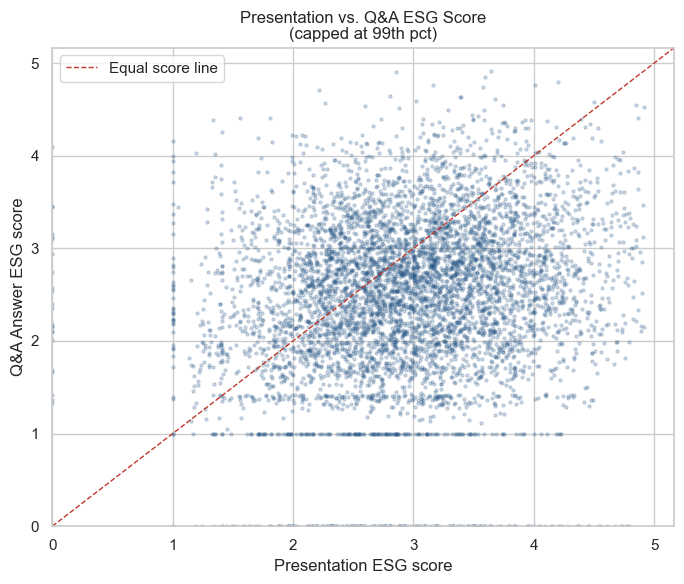

Calls with more ESG in Presentation: 4,026 (67.6%)
Calls with more ESG in Q&A answers:  1,927 (32.3%)


In [7]:
plot_df = df[["pres_esg_total", "ans_esg_total"]].dropna()
cap = plot_df.quantile(0.99).max()
plot_df = plot_df[(plot_df <= cap).all(axis=1)]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(plot_df["pres_esg_total"], plot_df["ans_esg_total"],
           alpha=0.2, s=5, color=BLUE)
lim = cap * 1.05
ax.plot([0, lim], [0, lim], "--", color=RED, linewidth=1, label="Equal score line")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Presentation ESG score")
ax.set_ylabel("Q&A Answer ESG score")
ax.set_title("Presentation vs. Q&A ESG Score\n(capped at 99th pct)")
ax.legend()
plt.tight_layout()
plt.show()

higher_in_pres = (df["pres_esg_total"] > df["ans_esg_total"]).sum()
higher_in_qanda = (df["ans_esg_total"] > df["pres_esg_total"]).sum()
print(f"Calls with more ESG in Presentation: {higher_in_pres:,} ({higher_in_pres/len(df)*100:.1f}%)")
print(f"Calls with more ESG in Q&A answers:  {higher_in_qanda:,} ({higher_in_qanda/len(df)*100:.1f}%)")

## 8. Top Companies by ESG Score

Which companies have the highest average ESG scores across all their calls?

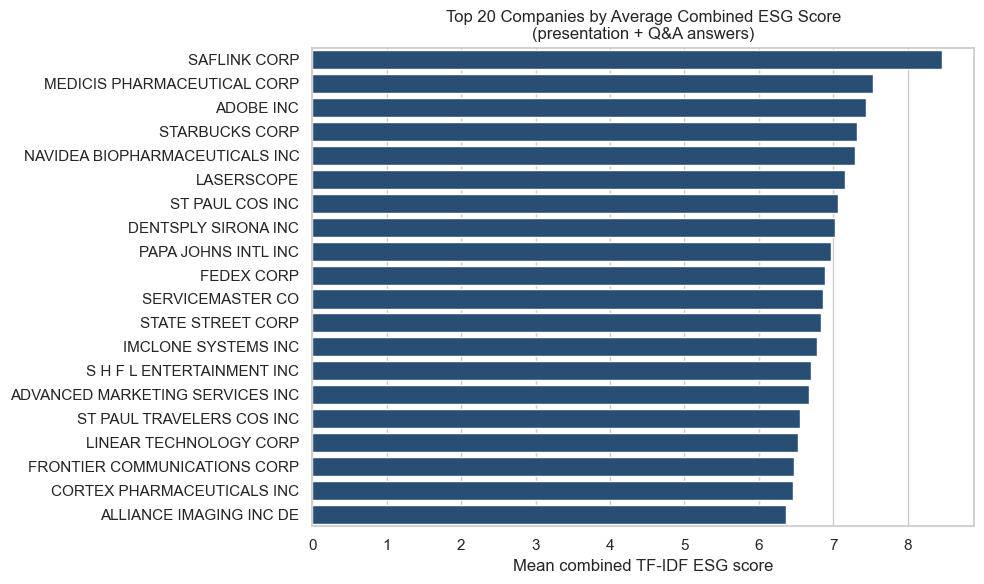

,Company,combined_esg_score
0,SAFLINK CORP,8.470160
1,MEDICIS PHARMACEUTICAL CORP,7.538456
2,ADOBE INC,7.440818
3,STARBUCKS CORP,7.319408
4,NAVIDEA BIOPHARMACEUTICALS INC,7.296064
5,LASERSCOPE,7.157794
6,ST PAUL COS INC,7.062881
7,DENTSPLY SIRONA INC,7.021387
8,PAPA JOHNS INTL INC,6.973192
9,FEDEX CORP,6.885838


In [8]:
N = 20
top_firms = (
    df.groupby("comnam")[["pres_esg_total", "ans_esg_total"]]
    .mean()
    .sum(axis=1)
    .nlargest(N)
    .reset_index()
    .rename(columns={0: "combined_esg_score", "comnam": "Company"})
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_firms, y="Company", x="combined_esg_score", ax=ax, color=BLUE)
ax.set_title(f"Top {N} Companies by Average Combined ESG Score\n(presentation + Q&A answers)")
ax.set_xlabel("Mean combined TF-IDF ESG score")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

top_firms

## 9. Sample Texts from High-ESG Calls

Display the presentation text of the single call with the highest score for each ESG dimension, to qualitatively inspect what high-scoring calls actually say.

In [9]:
SEGMENTS_DIR = Path("../data/processed/Transcripts/Call_segments")
PREVIEW_CHARS = 2000  # characters to show per text

def load_segment(filename: str, suffix: str) -> str:
    """Load a segment text file given the original filename (with or without .txt)."""
    stem = filename.replace(".txt", "").strip('"')
    path = SEGMENTS_DIR / f"{stem}_{suffix}.txt"
    if path.exists():
        return path.read_text(encoding="utf-8")
    return "(file not found)"

def show_call(row, suffix="presentation", chars=PREVIEW_CHARS):
    """Print company info and a text preview for a single call row."""
    text = load_segment(row["filename"], suffix)
    print(f"Company : {row['comnam']}")
    print(f"Date    : {row['date_call']}")
    print(f"File    : {row['filename']}")
    print(f"Score   : {row[score_col]:.4f}  (column: {score_col})")
    print("-" * 70)
    print(text[:chars])
    print("..." if len(text) > chars else "")
    print()

dimensions = {
    "Overall ESG (Presentation)":   "pres_esg_total",
    "Environmental (Presentation)": "pres_esg_environmental",
    "Social (Presentation)":        "pres_esg_social",
    "Governance (Presentation)":    "pres_esg_governance",
}

for title, score_col in dimensions.items():
    top_row = df.loc[df[score_col].idxmax()]
    print("=" * 70)
    print(f"  HIGHEST {title.upper()}")
    print("=" * 70)
    show_call(top_row, suffix="presentation")

  HIGHEST OVERALL ESG (PRESENTATION)
Company : CRAWFORD & CO
Date    : 10may2022
File    : 2022-May-10-CRDb.N-139989390838-transcript.txt
Score   : 6.0827  (column: pres_esg_total)
----------------------------------------------------------------------
Some of the matters to be discussed in this conference call and in the supplementary financial presentation may include forward-looking statements that involve risks and uncertainties. These statements may relate to, among other things, the impact of COVID-19, our expected future operating results and financial condition, our ability to grow our revenues and reduce our operating expenses, and expectations regarding our anticipated contributions to our underfunded defined benefit pension plans, collectability of our billed and unbilled accounts receivables, financial results from our recently completed acquisitions; our continued compliance with the financial and other covenants contained in our financing agreements, our long-term capital 